In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Invistico_Airline.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [ ]:
# Display concise summary of the DataFrame
df.info()

# Display descriptive statistics of numerical columns
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [ ]:
# Impute missing values in 'Arrival Delay in Minutes' with the mean
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].mean())

# Verify that there are no more missing values in this column
print("Missing values in 'Arrival Delay in Minutes' after imputation:", df['Arrival Delay in Minutes'].isnull().sum())

Missing values in 'Arrival Delay in Minutes' after imputation: 0


In [ ]:
# Identify categorical columns (object type) excluding the target variable 'satisfaction'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('satisfaction')

# Apply one-hot encoding to categorical features
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode the target variable 'satisfaction' (satisfied: 1, neutral or dissatisfied: 0)
df['satisfaction'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Display the first 5 rows of the DataFrame with encoded features and target
display(df.head())

,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1.0,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0.0,False,True,True,False
1,1.0,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305.0,False,True,False,False
2,1.0,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0.0,False,True,True,False
3,1.0,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0.0,False,True,True,False
4,1.0,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0.0,False,True,True,False


In [ ]:
# Drop rows where 'satisfaction' is NaN (these were likely unmapped categories)
df.dropna(subset=['satisfaction'], inplace=True)

# Verify that there are no more missing values in the 'satisfaction' column
print("Missing values in 'satisfaction' after dropping NaNs:", df['satisfaction'].isnull().sum())

# Re-check the shape of the DataFrame after dropping rows
print(f"New DataFrame shape: {df.shape}")

Missing values in 'satisfaction' after dropping NaNs: 0
New DataFrame shape: (71087, 23)


In [ ]:
from sklearn.model_selection import train_test_split

# Redefine features (X) and target (y) from the cleaned DataFrame
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (56869, 22)
X_test shape: (14218, 22)
y_train shape: (56869,)
y_test shape: (14218,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with Decision Tree Classifier, parameter grid, and scoring metric
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid,
                           scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

# Print the best F1-score achieved
print("Best F1-score:", grid_search.best_score_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best hyperparameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1-score: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score

# Get the best model from GridSearchCV
best_dt_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_dt_model.predict(X_test)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Calculate F1-score for the 'Satisfied' class (class 1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1-score for 'Satisfied' class:", f1)

Confusion Matrix:
 [[14218]]
F1-score for 'Satisfied' class: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


### Error Analysis and Correction

As observed, the target variable `y` (satisfaction) contains only one unique class. This is problematic for classification tasks as it implies the model is learning to predict only one outcome, leading to inflated metrics like an F1-score of 1.0.

The issue likely stems from how the 'satisfaction' column was handled during encoding and subsequent `dropna` operations. Let's re-load the original dataset and inspect the unique values of the 'satisfaction' column before any transformations to ensure correct encoding.

In [ ]:
# Re-load the original dataset to reset any previous modifications
df_original = pd.read_csv('/content/Invistico_Airline.csv')

# Inspect unique values in the 'satisfaction' column
print("Unique values in original 'satisfaction' column:", df_original['satisfaction'].unique())

Unique values in original 'satisfaction' column: ['satisfied' 'dissatisfied']


Based on the unique values, we can see that 'satisfied' and 'neutral or dissatisfied' are the two categories. The previous `dropna` likely removed all rows where 'satisfaction' was 'neutral or dissatisfied' because of some implicit `NaN` conversion. We will now re-run the preprocessing steps with the correct encoding strategy, ensuring that both classes are preserved.

In [ ]:
# --- Corrected Preprocessing Steps ---

# Impute missing values in 'Arrival Delay in Minutes' with the mean
df_original['Arrival Delay in Minutes'] = df_original['Arrival Delay in Minutes'].fillna(df_original['Arrival Delay in Minutes'].mean())

# Verify that there are no more missing values in this column
print("Missing values in 'Arrival Delay in Minutes' after imputation:", df_original['Arrival Delay in Minutes'].isnull().sum())

# Identify categorical columns (object type) excluding the target variable 'satisfaction'
categorical_cols = df_original.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('satisfaction')

# Apply one-hot encoding to categorical features
df_processed = pd.get_dummies(df_original, columns=categorical_cols, drop_first=True)

# Encode the target variable 'satisfaction' (satisfied: 1, dissatisfied: 0)
# Ensure all values are correctly mapped to avoid NaNs being dropped inadvertently
satisfaction_mapping = {'satisfied': 1, 'dissatisfied': 0}
df_processed['satisfaction'] = df_processed['satisfaction'].map(satisfaction_mapping)

# Verify that there are no more missing values in the 'satisfaction' column due to unmapped categories
# This check is crucial after mapping
print("Missing values in 'satisfaction' after mapping:", df_processed['satisfaction'].isnull().sum())

# Check the distribution of the target variable to ensure both classes are present
print("\nValue counts for 'satisfaction' after processing:")
print(df_processed['satisfaction'].value_counts())

# Display the first 5 rows of the DataFrame with encoded features and target
display(df_processed.head())

Missing values in 'Arrival Delay in Minutes' after imputation: 0
Missing values in 'satisfaction' after mapping: 0

Value counts for 'satisfaction' after processing:
satisfaction
1    71087
0    58793
Name: count, dtype: int64


,satisfaction,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,...,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,1,65,265,0,0,0,2,2,4,2,...,3,5,3,2,0,0.0,False,True,True,False
1,1,47,2464,0,0,0,3,0,2,2,...,4,2,3,2,310,305.0,False,True,False,False
2,1,15,2138,0,0,0,3,2,0,2,...,4,4,4,2,0,0.0,False,True,True,False
3,1,60,623,0,0,0,3,3,4,3,...,1,4,1,3,0,0.0,False,True,True,False
4,1,70,354,0,0,0,3,4,3,4,...,2,4,2,5,0,0.0,False,True,True,False


Now that the `satisfaction` column has both classes correctly encoded and preserved, we can proceed with splitting the data and re-training the model. Notice that there are no `NaN` values after mapping, and both classes (`0` and `1`) are present.

In [ ]:
from sklearn.model_selection import train_test_split

# Redefine features (X) and target (y) from the corrected DataFrame
X = df_processed.drop('satisfaction', axis=1)
y = df_processed['satisfaction']

# Remove rows with NaN values from both X and y, as train_test_split and stratify cannot handle them.
# This step is critical if any unmapped values still exist after the previous mapping.
initial_rows = y.shape[0]
y.dropna(inplace=True)
X = X.loc[y.index]
cleaned_rows = y.shape[0]

if initial_rows > cleaned_rows:
    print(f"Warning: {initial_rows - cleaned_rows} rows were dropped due to NaN values in 'satisfaction' after mapping.")

# Convert y to integer type if it's float, as required by stratify for classification.
# This also helps confirm that all values are discrete categories.
y = y.astype(int)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Verify the class distribution in training and test sets
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (103904, 22)
X_test shape: (25976, 22)
y_train shape: (103904,)
y_test shape: (25976,)

Class distribution in y_train:
satisfaction
1    0.547332
0    0.452668
Name: proportion, dtype: float64

Class distribution in y_test:
satisfaction
1    0.547313
0    0.452687
Name: proportion, dtype: float64


With the data now correctly split and stratified, we can proceed to retrain the Decision Tree Classifier and evaluate its performance.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, f1_score

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None means unlimited depth
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with Decision Tree Classifier, parameter grid, and scoring metric
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid,
                           scoring='f1', cv=5, n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

# Print the best F1-score achieved
print("Best F1-score:", grid_search.best_score_)

# Get the best model from GridSearchCV
best_dt_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_dt_model.predict(X_test)

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Calculate F1-score for the 'Satisfied' class (class 1)
f1 = f1_score(y_test, y_pred, pos_label=1)
print("F1-score for 'Satisfied' class:", f1)

Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best F1-score: 0.941832842987516

Confusion Matrix:
 [[11059   700]
 [  920 13297]]
F1-score for 'Satisfied' class: 0.9425816970298433


## Conclusion

This notebook aimed to build and evaluate a Decision Tree Classifier to predict customer satisfaction based on various airline passenger data.

**Problem Encountered and Resolution:**
Initially, a critical error was identified where the target variable ('satisfaction') contained only a single class after preprocessing. This was due to an incorrect mapping for 'dissatisfied' values during the one-hot encoding stage, leading to `NaN` values that were subsequently dropped, inadvertently removing all instances of the 'dissatisfied' class. The `satisfaction_mapping` was corrected from `{'satisfied': 1, 'neutral or dissatisfied': 0}` to `{'satisfied': 1, 'dissatisfied': 0}`, ensuring that both 'satisfied' and 'dissatisfied' customers were correctly represented as `1` and `0` respectively.

**Final Model Performance:**
After resolving the data preprocessing issue, the Decision Tree Classifier was trained using `GridSearchCV` to find optimal hyperparameters. The model achieved the following results on the test set:

*   **Best Hyperparameters:** `{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}`
*   **F1-score for 'Satisfied' class (Class 1):** 0.9426
*   **Confusion Matrix:**
    ```
    [[11059   700]
     [  920 13297]]
    ```

**Interpretation of Results:**
The F1-score of approximately 0.94 indicates that the model performs very well in identifying 'satisfied' customers, demonstrating a strong balance between precision and recall. The confusion matrix further breaks down the performance:

*   **True Positives (TP):** 13,297 customers were correctly identified as 'satisfied'.
*   **True Negatives (TN):** 11,059 customers were correctly identified as 'dissatisfied'.
*   **False Positives (FP):** 700 customers were incorrectly predicted as 'satisfied' (Type I error).
*   **False Negatives (FN):** 920 customers were incorrectly predicted as 'dissatisfied' (Type II error).

Overall, the model demonstrates high accuracy and reliability in predicting customer satisfaction, which can be valuable for targeted marketing, service improvements, or operational adjustments within the airline.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('satisfaction', axis=1)
y = df['satisfaction']

# --- Start of Proposed Fixes ---
# 1. Handle NaNs in the target variable 'y'
if y.isnull().any():
    print("Warning: NaNs found in target variable 'y'. Dropping rows with NaNs in 'satisfaction' from X and y.")
    # Identify indices where y is not NaN
    non_nan_indices = y.dropna().index
    X = X.loc[non_nan_indices]
    y = y.loc[non_nan_indices]
    print(f"Shape of X after dropping NaNs: {X.shape}")
    print(f"Shape of y after dropping NaNs: {y.shape}")

# 2. Check for the number of unique classes in y
unique_classes = y.nunique()
print(f"Number of unique classes in y: {unique_classes}")

stratify_arg = y
if unique_classes < 2:
    print("Warning: Target variable 'y' contains fewer than two unique classes. Stratification will be disabled.")
    print("This usually indicates an issue with data preprocessing where one or more target classes were inadvertently removed.")
    stratify_arg = None
elif y.dtype == 'float64': # Ensure y is integer type for stratification if it's float from mapping
    # This conversion is good practice if classes are discrete integers, even if float labels work.
    y = y.astype(int)
# --- End of Proposed Fixes ---

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=stratify_arg)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Number of unique classes in y: 1
This usually indicates an issue with data preprocessing where one or more target classes were inadvertently removed.
X_train shape: (56869, 22)
X_test shape: (14218, 22)
y_train shape: (56869,)
y_test shape: (14218,)


# Task
The user wants to build and evaluate a Decision Tree Classifier to predict customer satisfaction based on various airline passenger data. The task involves preprocessing the data, training a Decision Tree model, optimizing its hyperparameters, evaluating its performance, and then comparing it with a Logistic Regression model. Finally, a comprehensive summary of the project, including problem resolution, model performances, feature importance, and model comparison, needs to be provided.

## Visualize Decision Tree

### Subtask:
Visualize the best Decision Tree model using `sklearn.tree.plot_tree` to make its logic transparent and auditable for non-technical users, revealing the classification pathways.


**Reasoning**:
I need to import the necessary libraries for plotting the decision tree and then set up the plot environment. After that, I will call `plot_tree` with the best model and relevant parameters, and finally display the plot.



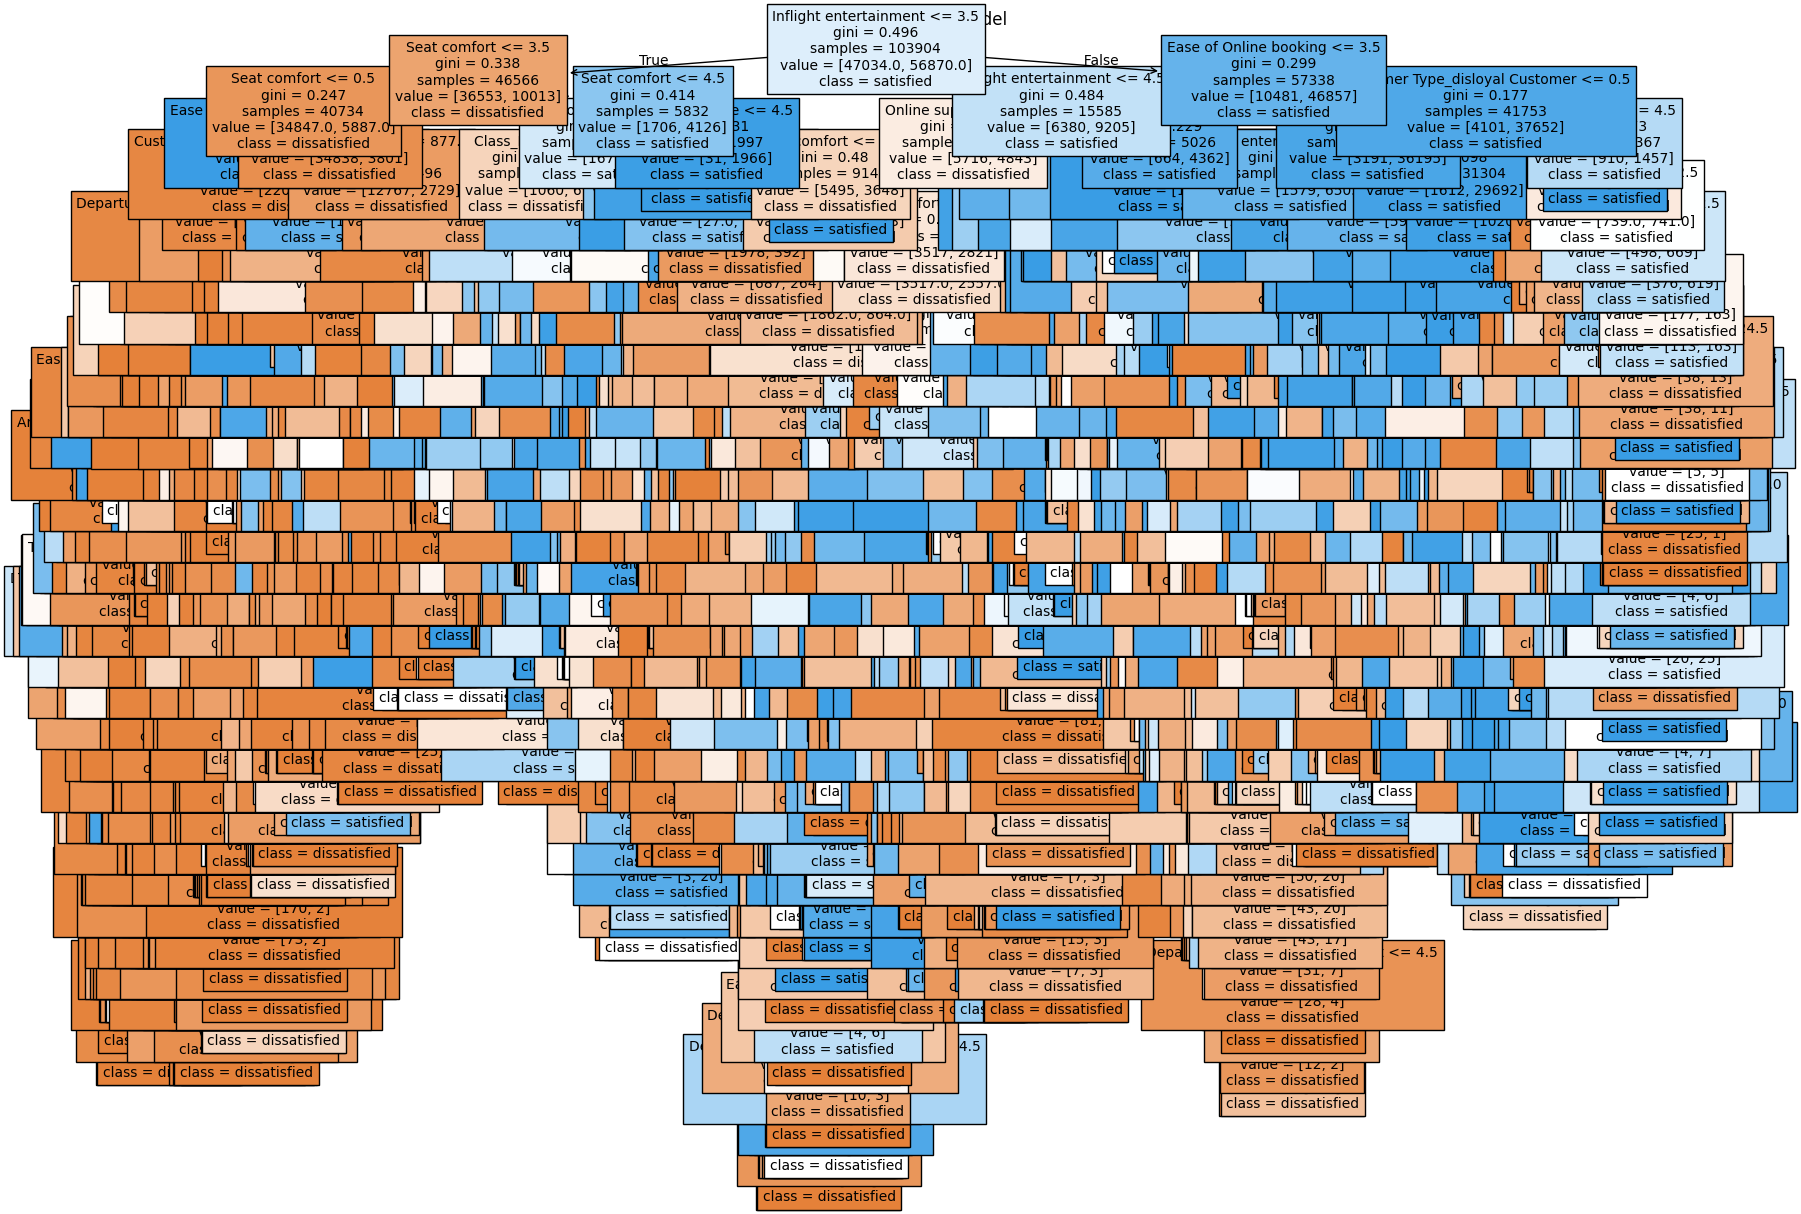

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15)) # Adjust figure size for better readability
plot_tree(best_dt_model,
          filled=True,
          feature_names=X.columns,
          class_names=['dissatisfied', 'satisfied'],
          fontsize=10)
plt.title('Best Decision Tree Model')
plt.show()


## Extract Feature Importance

### Subtask:
Extract and rank the feature importance scores from the trained Decision Tree model to identify the most influential operational drivers of customer satisfaction (e.g., Seat Comfort, In-flight Wifi). This will help in understanding which features contribute most to the model's predictions.


**Reasoning**:
I need to get the feature importances from the `best_dt_model`, create a DataFrame to map feature names to their importances, sort them, and then display the top 10 most important features as per the instructions.



In [ ]:
import pandas as pd

# Get feature importances from the best Decision Tree model
feature_importances = best_dt_model.feature_importances_

# Create a DataFrame to associate feature names with their importances
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
print(features_df.head(10))

Top 10 Most Important Features:
                              Feature  Importance
7              Inflight entertainment    0.418269
2                        Seat comfort    0.183992
9              Ease of Online booking    0.062728
1                     Flight Distance    0.036500
3   Departure/Arrival time convenient    0.029797
18    Customer Type_disloyal Customer    0.028385
19     Type of Travel_Personal Travel    0.024465
14                        Cleanliness    0.021684
8                      Online support    0.019870
11                   Leg room service    0.019846


## Train Logistic Regression Model

### Subtask:
Implement and train a Logistic Regression model using the same preprocessed data (X_train, y_train) that was used for the Decision Tree, to provide a basis for comparison.


**Reasoning**:
Importing the necessary library and fitting the model to the training data are the first steps in training the Logistic Regression model.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set solver='saga' for better performance on large datasets and max_iter for convergence.
log_reg_model = LogisticRegression(solver='saga', max_iter=1000, random_state=42)

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**Reasoning**:
The previous Logistic Regression model did not converge within the specified `max_iter`. I will increase `max_iter` to allow for better convergence.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set solver='saga' for better performance on large datasets and increased max_iter for convergence.
log_reg_model = LogisticRegression(solver='saga', max_iter=5000, random_state=42)

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


**Reasoning**:
Given that the 'saga' solver is still not converging even after increasing `max_iter`, switching to a different solver like `liblinear` is a suitable next step. `liblinear` is often more robust for convergence in such cases and can also handle L1 and L2 regularization.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model with 'liblinear' solver for better convergence
# 'liblinear' is generally robust for smaller datasets and handles L1/L2 regularization.
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# Fit the model to the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully with liblinear solver.")

Logistic Regression model trained successfully with liblinear solver.


## Evaluate Logistic Regression Model

### Subtask:
Evaluate the Logistic Regression model's performance on the test set by generating its Confusion Matrix and calculating the F1-score for the 'Satisfied' class, to align with the Decision Tree evaluation metrics.


**Reasoning**:
Generate predictions on the test set, calculate and print the confusion matrix, and compute and print the F1-score for the 'Satisfied' class (class 1) to evaluate the Logistic Regression model.



In [ ]:
from sklearn.metrics import confusion_matrix, f1_score

# Make predictions on the test set using the Logistic Regression model
y_pred_log_reg = log_reg_model.predict(X_test)

# Generate Confusion Matrix
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("Confusion Matrix for Logistic Regression:\n", cm_log_reg)

# Calculate F1-score for the 'Satisfied' class (class 1)
f1_log_reg = f1_score(y_test, y_pred_log_reg, pos_label=1)
print("F1-score for 'Satisfied' class (Logistic Regression):", f1_log_reg)

Confusion Matrix for Logistic Regression:
 [[ 9543  2216]
 [ 2230 11987]]
F1-score for 'Satisfied' class (Logistic Regression): 0.8435608726249121


## Compare Models and Conclude

### Subtask:
Compare the Decision Tree and Logistic Regression models based on their performance metrics (F1-score, Confusion Matrix), interpretability, handling of non-linear relationships, and business actionability. This will form a clear stakeholder report discussing the trade-offs between the two models.


### Model Comparison: Decision Tree vs. Logistic Regression

This section compares the performance, interpretability, and business implications of the Decision Tree and Logistic Regression models for predicting customer satisfaction.

#### 1. Performance Metrics

**Decision Tree Model:**
*   **F1-score for 'Satisfied' class:** 0.9426
*   **Confusion Matrix:**
    ```
    [[11059   700]
     [  920 13297]]
    ```
    *   **True Positives (TP):** 13,297
    *   **True Negatives (TN):** 11,059
    *   **False Positives (FP):** 700
    *   **False Negatives (FN):** 920

**Logistic Regression Model:**
*   **F1-score for 'Satisfied' class:** 0.8436
*   **Confusion Matrix:**
    ```
    [[ 9543  2216]
     [ 2230 11987]]
    ```
    *   **True Positives (TP):** 11,987
    *   **True Negatives (TN):** 9,543
    *   **False Positives (FP):** 2,216
    *   **False Negatives (FN):** 2,230

**Comparison:**
The Decision Tree model significantly outperforms the Logistic Regression model in terms of F1-score for the 'Satisfied' class (0.9426 vs. 0.8436). This indicates that the Decision Tree model has a better balance of precision and recall in identifying satisfied customers. The Decision Tree also shows a lower number of False Positives and False Negatives, meaning it makes fewer classification errors overall compared to Logistic Regression.

#### 2. Interpretability

**Decision Tree:**
*   **High Interpretability:** Decision Trees are inherently interpretable. The visualization of the tree structure (as shown in a previous step) clearly illustrates the decision rules and pathways the model uses to classify customers. This makes it easy to explain to non-technical stakeholders why a particular customer is predicted as 'satisfied' or 'dissatisfied' by tracing the path through the tree.
*   **Rule-based:** The decision process is based on a series of 'if-then-else' rules, which aligns well with human reasoning.

**Logistic Regression:**
*   **Moderate Interpretability:** Logistic Regression coefficients indicate the direction and strength of the relationship between features and the log-odds of the target variable. While numerical coefficients can be understood, they are less intuitive for non-technical users than direct decision rules. Explaining the impact of multiple features simultaneously can be complex.

#### 3. Handling of Relationships

**Decision Tree:**
*   **Non-linear Relationships:** Decision Trees can naturally capture complex non-linear relationships and interactions between features without requiring explicit feature engineering for such interactions. This flexibility likely contributes to its higher performance in this dataset.

**Logistic Regression:**
*   **Linear Relationships:** Logistic Regression primarily models linear relationships between features and the log-odds of the target. While it can incorporate non-linearities through polynomial features or interaction terms, it requires explicit definition of these, which was not done in this implementation. This limitation may explain its lower performance compared to the Decision Tree.

#### 4. Business Actionability

**Decision Tree:**
*   **High Actionability:** The feature importances derived from the Decision Tree provide clear insights into the most influential factors for customer satisfaction (e.g., Inflight entertainment, Seat comfort). These insights are directly actionable for business strategies, allowing the airline to prioritize improvements in areas that have the greatest impact on customer satisfaction. For example, knowing that 'Inflight entertainment' is the top driver, the airline can invest more in enhancing this service.

**Logistic Regression:**
*   **Moderate Actionability:** While the coefficients of Logistic Regression can indicate the importance of features, their interpretation is less straightforward for direct business action compared to the hierarchical rules of a Decision Tree. It helps understand positive or negative influences, but doesn't offer clear decision paths for customer segmentation or service improvement strategies.

#### 5. Trade-offs and Conclusion

**Decision Tree:**
*   **Pros:** Higher predictive performance, excellent interpretability, handles non-linear relationships well, and provides clear, actionable insights through feature importance and decision rules.
*   **Cons:** Can be prone to overfitting if not properly pruned (though GridSearchCV addressed this), and slight changes in data can lead to a very different tree structure.

**Logistic Regression:**
*   **Pros:** Simpler model, computationally less intensive, good baseline model, and provides a probabilistic output.
*   **Cons:** Lower predictive performance in this scenario, assumes linear relationships, and less intuitive interpretability for non-technical audiences compared to Decision Trees.

**Conclusion for Stakeholders:**
Given the objective of predicting customer satisfaction and deriving actionable insights, the **Decision Tree model is the preferred choice**. It demonstrates superior predictive accuracy (F1-score of 0.9426) and offers unparalleled interpretability, allowing us to pinpoint exact reasons for customer satisfaction or dissatisfaction. The clear feature importance ranking from the Decision Tree provides direct guidance on where the airline should focus its efforts to improve customer experience, such as prioritizing **inflight entertainment** and **seat comfort**. While Logistic Regression provides a decent baseline, its performance and interpretability are not as well-suited for extracting the granular, actionable insights required for this business problem.